In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [33]:
print("Shape:", df.shape)
print(df.columns.tolist())
df.isnull().sum()

Shape: (50000, 2)
['review', 'sentiment']


,0
review,0
sentiment,0


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


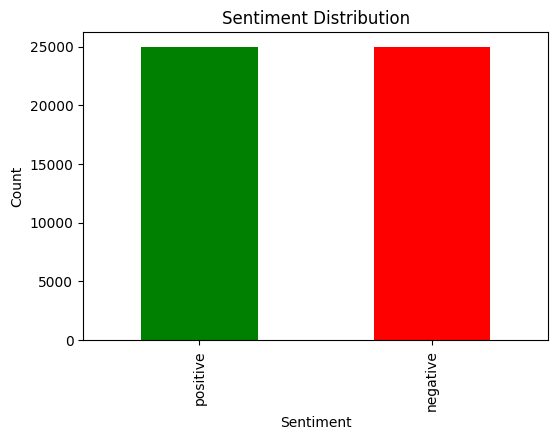

In [34]:
print(df['sentiment'].value_counts())

plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [35]:
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags (common in this dataset)
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra whitespace
    return text

df['cleaned_review'] = df['review'].apply(clean_text)
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


In [36]:
X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (40000, 5000)
Test shape: (10000, 5000)


In [38]:
# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Naive Bayes Accuracy: 0.8514
Logistic Regression Accuracy: 0.8866


In [39]:
from sklearn.metrics import classification_report

print("=== Naive Bayes ===")
print(classification_report(y_test, nb_pred))

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))

=== Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      5000
    positive       0.85      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



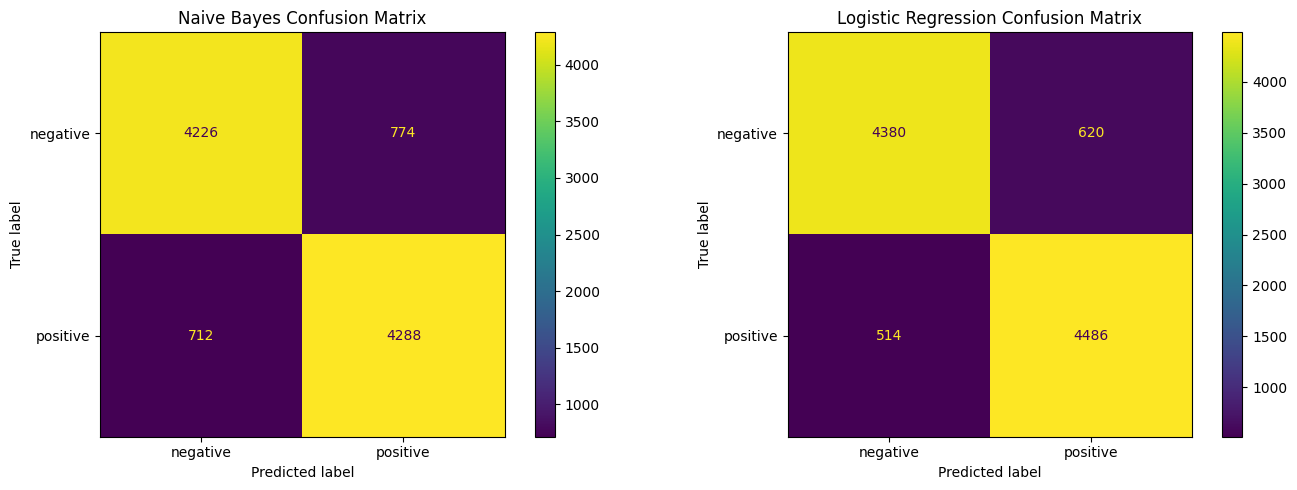

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14,5))

ConfusionMatrixDisplay.from_predictions(y_test, nb_pred, ax=axes[0])
axes[0].set_title('Naive Bayes Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')

plt.tight_layout()
plt.show()

In [41]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
lr_pred_series = pd.Series(lr_pred)

misclassified = X_test_reset[y_test_reset != lr_pred_series]
misclassified_actual = y_test_reset[y_test_reset != lr_pred_series]
misclassified_pred = lr_pred_series[y_test_reset != lr_pred_series]

for i in range(5):
    idx = misclassified.index[i]
    print(f"Review: {misclassified.iloc[i][:200]}...")
    print(f"Actual: {misclassified_actual.iloc[i]} | Predicted: {misclassified_pred.iloc[i]}")
    print("---")

Review: the story of the bride fair is an amusing and engaging one and it is to the filmmakers credit that he sets out to portray rural minnesotans with the same respect ordinarily reserved for coastdwellers ...
Actual: negative | Predicted: positive
---
Review: this movie is really wack there is really nothing nice i can say about it besides the moral truth expressed in the films climax concerning people in the neighborhood participating in the fight against...
Actual: negative | Predicted: positive
---
Review: i admit creating great expectations before watching because some friends mentioned it and they are not pervs as a must see and it is a must see just dont expect to see something outbreakingthe freudia...
Actual: positive | Predicted: negative
---
Review: the film listed here as having been made in is not the film which is available from something weird video in their drivers ed scare films vol for one thing the version is in color swv has on this disc...
Actual: negative | Pred

# **Error Analysis**:
Most misclassifications stem from the model's inability to understand negation ("nothing nice") and context-dependent phrasing (positive words used ironically or as setup for later criticism, like "amusing" or "great expectations"). Since TF-IDF treats words independently without understanding sentence structure or sarcasm, reviews with mixed sentiment, understated criticism, or plot-descriptive language without strong emotional words are the most error-prone.

## Conclusion:
Logistic Regression (88.66% accuracy) outperformed Naive Bayes (85.14% accuracy) on this sentiment classification task, with better precision and recall across both classes. This approach could serve real-world applications like automatically flagging negative product reviews for customer service follow-up, monitoring brand sentiment on social media, or filtering feedback for support teams though a more advanced model (e.g., incorporating negation handling or using deep learning) would improve accuracy further on nuanced or sarcastic reviews.